In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf

from arch import arch_model
import warnings
warnings.filterwarnings('ignore')

In [2]:
# load in data
df = pd.read_csv('stock_1.csv')

# check size of data
unique_time_ids = df["time_id"].unique()
print(len(unique_time_ids))

3830


In [3]:
# Check if for any given time_id, there are duplicate seconds_in_bucket rows
dup_check = df.duplicated(subset=["time_id", "seconds_in_bucket"])
if dup_check.any():
    print("Duplicates found for time_id and seconds_in_bucket!")
    display(df[dup_check])
else:
    print("No duplicates: Each (time_id, seconds_in_bucket) pair is unique.")

No duplicates: Each (time_id, seconds_in_bucket) pair is unique.


Many models (eg garch and arima) assume equally spaced observations. lets clean the dataset such that we create equally spaced observations. so that we don't have future data leakage, we'll make sure that the past prices are carried forwards, and future prices are absolutely NOT carried backwards. we'll make this a reproducable function so we can apply it to both the train and test datasets

In [4]:
def make_equally_spaced(df, time_ids=None):
    """
    For each time_id, ensure equally spaced seconds_in_bucket observations from 0 to 599 (inclusive).
    Missing rows are forward-filled from past values only (no future leakage).
    Returns a new DataFrame.
    """
    # Allow operation on a subset of time_ids for efficiency/testing
    if time_ids is None:
        time_ids = df["time_id"].unique()
    df_out_list = []
    feature_cols = list(df.columns)
    for tid in time_ids:
        sub = df[df["time_id"] == tid].sort_values("seconds_in_bucket")
        # make a reindexing frame from 0 to 599 for this tid
        idx = pd.Index(range(600), name="seconds_in_bucket")
        sub = sub.set_index("seconds_in_bucket")
        # restore time_id col for as_indexed DataFrame
        sub["time_id"] = tid
        reindexed = sub.reindex(idx)
        reindexed["time_id"] = tid
        # forward fill ONLY, so NaNs at front stay NaN -- should be fine as market always opens with a tick
        reindexed = reindexed.ffill()
        # reset for downstream
        reindexed = reindexed.reset_index()
        df_out_list.append(reindexed)
    result = pd.concat(df_out_list, ignore_index=True)
    # If needed, reorder columns to original order
    result = result[df.columns]
    return result

# Apply to train and test
df = make_equally_spaced(df)


In [5]:
# note this is safe for the train and test sets
def create_new_cols(df):
    wap_num = (
        df["bid_price1"] * df["ask_size1"] + df["ask_price1"] * df["bid_size1"] +
        df["bid_price2"] * df["ask_size2"] + df["ask_price2"] * df["bid_size2"]
    )
    wap_den = df["bid_size1"] + df["ask_size1"] + df["bid_size2"] + df["ask_size2"]
    df["weighted_price"] = wap_num / wap_den

    # make sure to group by time id so we don't get weird numbers when switching time ids
    df['log_price'] = np.log(df['weighted_price'])
    df['log_price_diff'] = df.groupby('time_id')['log_price'].diff()


    return df

df = create_new_cols(df)

df

,time_id,seconds_in_bucket,bid_price1,ask_price1,bid_price2,ask_price2,bid_size1,ask_size1,bid_size2,ask_size2,stock_id,weighted_price,log_price,log_price_diff
0,5,0,1.000754,1.001542,1.000689,1.001607,1.0,25.0,25.0,100.0,1.0,1.000857,0.000857,NaN
1,5,1,1.000754,1.001673,1.000689,1.001739,26.0,60.0,25.0,100.0,1.0,1.000953,0.000953,0.000096
2,5,2,1.000754,1.001411,1.000623,1.001476,1.0,25.0,25.0,125.0,1.0,1.000768,0.000767,-0.000185
3,5,3,1.000754,1.001542,1.000689,1.001607,125.0,25.0,126.0,36.0,1.0,1.001407,0.001406,0.000639
4,5,4,1.000754,1.001476,1.000623,1.001542,100.0,100.0,25.0,25.0,1.0,1.001109,0.001108,-0.000298
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2297995,32767,595,0.998911,0.999109,0.998812,0.999208,125.0,225.0,101.0,100.0,1.0,0.998993,-0.001008,0.000000
2297996,32767,596,0.998911,0.999109,0.998812,0.999208,125.0,225.0,101.0,100.0,1.0,0.998993,-0.001008,0.000000
2297997,32767,597,0.998911,0.999109,0.998812,0.999208,125.0,225.0,101.0,100.0,1.0,0.998993,-0.001008,0.000000
2297998,32767,598,0.998911,0.999109,0.998812,0.999208,125.0,225.0,101.0,100.0,1.0,0.998993,-0.001008,0.000000


We should plot an ACF and a PACF averaged across all the data

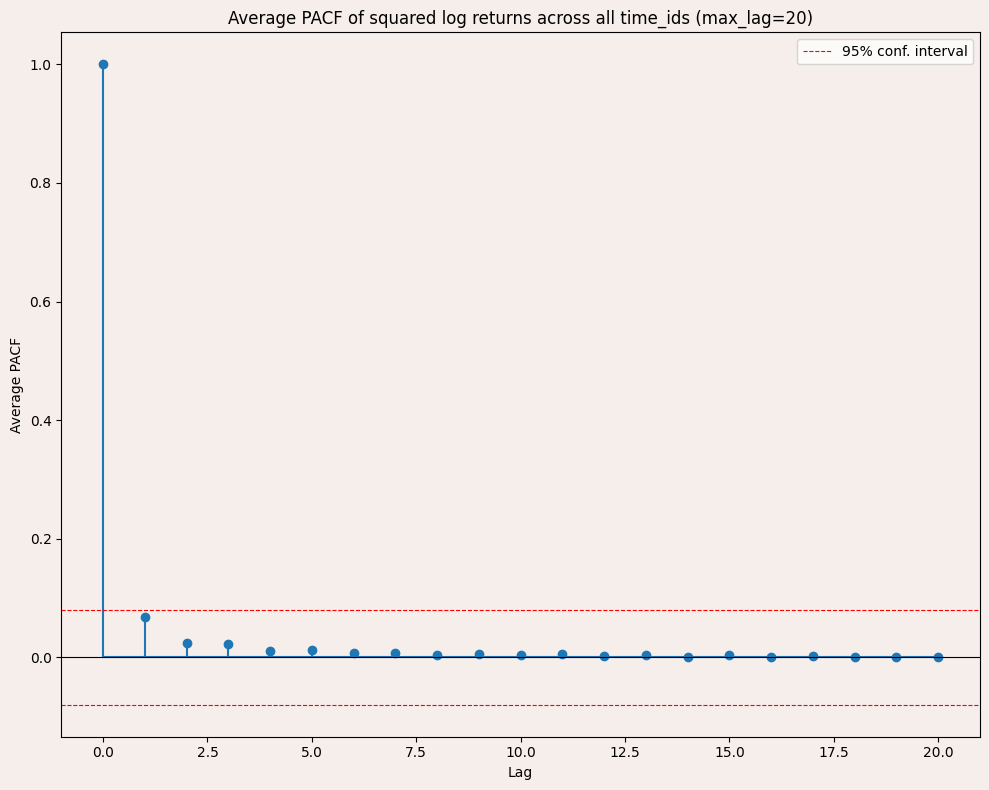

In [6]:
from statsmodels.tsa.stattools import pacf

max_lag = 20
all_pacf = []
all_n = []

for tid in df['time_id'].unique():
    chunk = df[df["time_id"] == tid].sort_values("seconds_in_bucket")
    vol_proxy = chunk["log_price_diff"].dropna().values ** 2
    if len(vol_proxy) < max_lag + 1 or np.std(vol_proxy) == 0:
        continue
    pacf_vals = pacf(vol_proxy, nlags=max_lag, method='ols')
    all_pacf.append(pacf_vals)
    all_n.append(len(vol_proxy))

average_pacf = np.mean(all_pacf, axis=0)
mean_n = int(np.mean(all_n)) if all_n else 0

# Statistical significance: For PACF, the approximate 95% CI for each lag is +/- 1.96/sqrt(N)
# We'll use the mean of all segment lengths for display
if mean_n > 0:
    conf_int = 1.96 / np.sqrt(mean_n)
else:
    conf_int = np.nan

fig, ax = plt.subplots(figsize=(10, 8), facecolor='#f6eeeb')
ax.set_facecolor('#f6eeeb')
ax.stem(range(max_lag + 1), average_pacf, basefmt="C0-")
ax.axhline(0, color="black", linewidth=0.8)
# Add horizontal significance lines
ax.axhline(conf_int, color="red", linestyle="--", linewidth=0.8, label="95% conf. interval")
ax.axhline(-conf_int, color="red", linestyle="--", linewidth=0.8)
ax.set_xlabel("Lag")
ax.set_ylabel("Average PACF")
ax.set_title(f"Average PACF of squared log returns across all time_ids (max_lag={max_lag})")
ax.legend()
fig.tight_layout()

fig.savefig("images/average_pacf.png", format="png", dpi=500, facecolor='#f6eeeb')

plt.show()


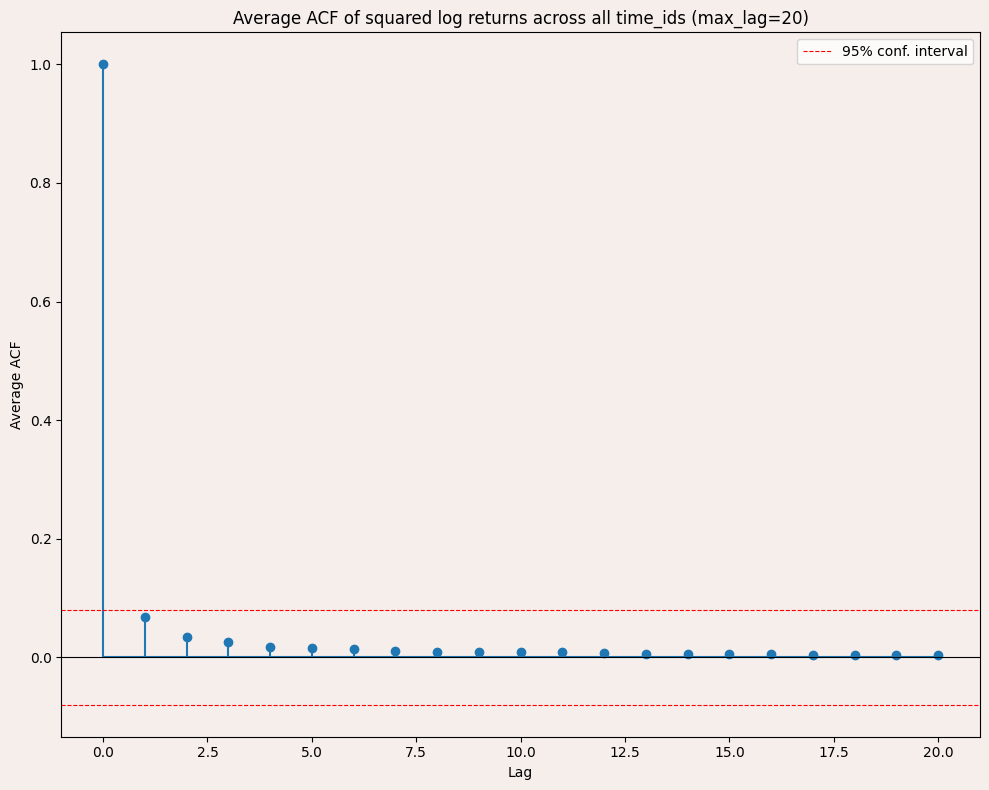

In [7]:
from statsmodels.tsa.stattools import acf

max_lag = 20
all_acf = []
all_n = []

for tid in df['time_id'].unique():
    chunk = df[df["time_id"] == tid].sort_values("seconds_in_bucket")
    vol_proxy = chunk["log_price_diff"].dropna().values ** 2
    if len(vol_proxy) < max_lag + 1 or np.std(vol_proxy) == 0:
        continue
    acf_vals = acf(vol_proxy, nlags=max_lag)
    all_acf.append(acf_vals)
    all_n.append(len(vol_proxy))

average_acf = np.mean(all_acf, axis=0)
mean_n = int(np.mean(all_n)) if all_n else 0

# Statistical significance: For ACF, the approximate 95% CI for each lag is +/- 1.96/sqrt(N)
# We'll use the mean of all segment lengths for display
if mean_n > 0:
    conf_int = 1.96 / np.sqrt(mean_n)
else:
    conf_int = np.nan

fig, ax = plt.subplots(figsize=(10, 8), facecolor='#f6eeeb')
ax.set_facecolor('#f6eeeb')
ax.stem(range(max_lag + 1), average_acf, basefmt="C0-")
ax.axhline(0, color="black", linewidth=0.8)
# Add horizontal significance lines
ax.axhline(conf_int, color="red", linestyle="--", linewidth=0.8, label="95% conf. interval")
ax.axhline(-conf_int, color="red", linestyle="--", linewidth=0.8)
ax.set_xlabel("Lag")
ax.set_ylabel("Average ACF")
ax.set_title(f"Average ACF of squared log returns across all time_ids (max_lag={max_lag})")
ax.legend()
fig.tight_layout()

fig.savefig("images/average_acf.png", format="png", dpi=500, facecolor='#f6eeeb')

plt.show()


## Modelling work

We get into some of the modelling below. First, fitting time series (GARCH) models, and then later on we'll do more typical supervised models

In [8]:
from arch import arch_model
from scipy import stats
from sklearn.base import clone
from sklearn.linear_model import LinearRegression, Lasso, RidgeCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold
import xgboost as xgb

# ── constants ─────────────────────────────────────────────────────────────────

HORIZON   = 30    # seconds held out as the forecast target per time_id
N_FOLDS   = 5     # five folds gives an 80/20 split each time

# ── 5-fold split on time_ids ──────────────────────────────────────────────────

all_time_ids = np.asarray(df['time_id'].unique())
kfold = KFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
cv_splits = []
for fold_id, (train_idx, test_idx) in enumerate(kfold.split(all_time_ids), start=1):
    cv_splits.append({
        'fold': fold_id,
        'train_ids': set(all_time_ids[train_idx].tolist()),
        'test_ids': set(all_time_ids[test_idx].tolist()),
    })

# Keep these names for standalone diagnostic cells such as the RV heatmaps.
# The main model comparison below uses every split in `cv_splits`.
train_time_ids = cv_splits[0]['train_ids']
test_time_ids = cv_splits[0]['test_ids']

print(f"Created {N_FOLDS} shuffled folds over {len(all_time_ids):,} time_ids")
for split in cv_splits:
    print(
        f"  Fold {split['fold']}: "
        f"train={len(split['train_ids']):,}, test={len(split['test_ids']):,}"
    )


Created 5 shuffled folds over 3,830 time_ids
  Fold 1: train=3,064, test=766
  Fold 2: train=3,064, test=766
  Fold 3: train=3,064, test=766
  Fold 4: train=3,064, test=766
  Fold 5: train=3,064, test=766


In [9]:
# ── feature engineering ───────────────────────────────────────────────────────

# Candidate feature grid: keep the notebook's 30-second target and evaluation,
# but give the ML models a wider volatility-history view. The RV-window
# diagnostic below is restricted to a training fold to avoid tuning on held-out
# time_ids. The 570-second feature from the modular experiments was avoided:
# after the first diff and 30-second holdout, the usable history is 569 returns.
RETURN_WINDOWS = [5, 10, 20, 30, 45, 60, 90, 120, 180, 240, 300,
                  330, 350, 380, 400, 410, 420, 430, 440, 450,
                  480, 500, 540, 560, 569]
ACF_WINDOWS    = [30, 60, 120, 300, 420, 569]
BOOK_WINDOWS   = [30, 60, 120, 300, 420]
EWMA_LAMBDAS   = [0.70, 0.80, 0.90, 0.94, 0.97, 0.985]
EPS            = 1e-9


def _ewma_name(lam):
    return f"EWMA_{str(lam).replace('.', '')}"


def _ret_autocorr(x, lag=1):
    if len(x) <= lag:
        return np.nan
    lag0, lag1 = x[:-lag], x[lag:]
    denom = np.std(lag0) * np.std(lag1)
    return float(np.mean((lag0 - lag0.mean()) * (lag1 - lag1.mean())) / denom) if denom > 0 else 0.0


def compute_features(returns, t, chunk_ob):
    """
    Compute feature vector from returns[0:t] and the matching order book rows.

    The original feature set is still present (RV_30/60/120/300, EWMA_094,
    ret_autocorr_30, order-book 30s features). This expands the ML feature set
    with longer realised-variance candidate windows, especially
    RV_350 / RV_400 / RV_420 / RV_450.
    """
    r  = returns[:t]
    r2 = r ** 2
    ob = chunk_ob.iloc[:t]

    feats = {
        'seconds_elapsed': float(t) / max(len(returns), 1),
        'n_obs': float(len(returns)),
        'cutoff': float(t),
        'last_return': float(r[-1]) if len(r) else np.nan,
        'abs_last_return': float(abs(r[-1])) if len(r) else np.nan,
    }

    for window in RETURN_WINDOWS:
        if t >= window:
            win = r[-window:]
            win2 = win ** 2
            sigma = np.std(win)
            feats[f'RV_{window}'] = float(np.mean(win2))
            feats[f'vol_{window}'] = float(np.sqrt(np.mean(win2)))
            feats[f'mean_abs_ret_{window}'] = float(np.mean(np.abs(win)))
            feats[f'mean_ret_{window}'] = float(np.mean(win))
            feats[f'max_abs_ret_{window}'] = float(np.max(np.abs(win)))
            feats[f'prop_zero_ret_{window}'] = float(np.mean(win == 0))
            feats[f'downside_RV_{window}'] = float(np.mean(win2[win < 0])) if np.any(win < 0) else 0.0
            feats[f'upside_RV_{window}'] = float(np.mean(win2[win > 0])) if np.any(win > 0) else 0.0
            feats[f'jump_count_{window}'] = float(np.sum(np.abs(win) > (3 * sigma + EPS)))
            feats[f'ret_q10_{window}'] = float(np.quantile(win, 0.10))
            feats[f'ret_q90_{window}'] = float(np.quantile(win, 0.90))
        else:
            for name in ['RV', 'vol', 'mean_abs_ret', 'mean_ret', 'max_abs_ret',
                         'prop_zero_ret', 'downside_RV', 'upside_RV',
                         'jump_count', 'ret_q10', 'ret_q90']:
                feats[f'{name}_{window}'] = np.nan

    for window in ACF_WINDOWS:
        if t >= window:
            win = r[-window:]
            feats[f'ret_autocorr_{window}'] = _ret_autocorr(win, lag=1)
            feats[f'ret_autocorr5_{window}'] = _ret_autocorr(win, lag=5)
        else:
            feats[f'ret_autocorr_{window}'] = np.nan
            feats[f'ret_autocorr5_{window}'] = np.nan

    r2_s = pd.Series(r2)
    for lam in EWMA_LAMBDAS:
        feats[_ewma_name(lam)] = float(r2_s.ewm(alpha=1 - lam, adjust=False).mean().iloc[-1])

    feats['vol_trend'] = feats['RV_30'] / (feats['RV_300'] + EPS)
    for short, long in [(5, 30), (10, 60), (30, 120), (30, 300),
                        (60, 300), (120, 420), (300, 420)]:
        feats[f'RV_ratio_{short}_{long}'] = feats[f'RV_{short}'] / (feats[f'RV_{long}'] + EPS)

    if len(ob) > 0:
        mid = (ob['bid_price1'] + ob['ask_price1']) / 2
        spread = (ob['ask_price1'] - ob['bid_price1']) / mid.replace(0, np.nan)
        total_l1 = ob['bid_size1'] + ob['ask_size1']
        total_l2 = (ob['bid_size2'] + ob['ask_size2']).replace(0, np.nan)
        depth = total_l1 + total_l2
        imbalance = (ob['bid_size1'] - ob['ask_size1']) / total_l1.replace(0, np.nan)
        pressure = (ob['bid_size1'] + ob['bid_size2'] - ob['ask_size1'] - ob['ask_size2']) / depth.replace(0, np.nan)
    else:
        spread = total_l1 = total_l2 = depth = imbalance = pressure = pd.Series(dtype=float)

    for window in BOOK_WINDOWS:
        if len(ob) >= window:
            idx = slice(len(ob) - window, len(ob))
            feats[f'mean_spread_{window}'] = float(spread.iloc[idx].mean())
            feats[f'std_spread_{window}'] = float(spread.iloc[idx].std())
            feats[f'mean_imbalance_{window}'] = float(imbalance.iloc[idx].mean())
            feats[f'std_imbalance_{window}'] = float(imbalance.iloc[idx].std())
            feats[f'depth_ratio_{window}'] = float((total_l1 / total_l2).iloc[idx].mean())
            feats[f'mean_depth_{window}'] = float(depth.iloc[idx].mean())
            feats[f'std_depth_{window}'] = float(depth.iloc[idx].std())
            feats[f'book_pressure_{window}'] = float(pressure.iloc[idx].mean())
        else:
            for name in ['mean_spread', 'std_spread', 'mean_imbalance', 'std_imbalance',
                         'depth_ratio', 'mean_depth', 'std_depth', 'book_pressure']:
                feats[f'{name}_{window}'] = np.nan

    return feats



In [10]:
# ── ML dataset builder ────────────────────────────────────────────────────────

def _expanded_feature_cols():
    cols = ['seconds_elapsed', 'n_obs', 'cutoff', 'last_return', 'abs_last_return']
    for window in RETURN_WINDOWS:
        cols.extend([
            f'RV_{window}', f'vol_{window}', f'mean_abs_ret_{window}',
            f'mean_ret_{window}', f'max_abs_ret_{window}', f'prop_zero_ret_{window}',
            f'downside_RV_{window}', f'upside_RV_{window}', f'jump_count_{window}',
            f'ret_q10_{window}', f'ret_q90_{window}',
        ])
    for window in ACF_WINDOWS:
        cols.extend([f'ret_autocorr_{window}', f'ret_autocorr5_{window}'])
    cols.extend([_ewma_name(lam) for lam in EWMA_LAMBDAS])
    cols.append('vol_trend')
    for short, long in [(5, 30), (10, 60), (30, 120), (30, 300),
                        (60, 300), (120, 420), (300, 420)]:
        cols.append(f'RV_ratio_{short}_{long}')
    for window in BOOK_WINDOWS:
        cols.extend([
            f'mean_spread_{window}', f'std_spread_{window}',
            f'mean_imbalance_{window}', f'std_imbalance_{window}',
            f'depth_ratio_{window}', f'mean_depth_{window}',
            f'std_depth_{window}', f'book_pressure_{window}',
        ])
    return cols


FEATURE_COLS = _expanded_feature_cols()

OB_COLS = ['bid_price1', 'ask_price1', 'bid_size1', 'ask_size1', 'bid_size2', 'ask_size2']


def build_ml_dataset(df, time_ids, horizon=HORIZON):
    """
    For each time_id in `time_ids`, compute feature vector from
    returns[0 : n-horizon] and target = mean(returns[n-horizon : n]²).
    Returns X (DataFrame), y (Series), and the corresponding time_ids.
    """
    rows = []
    for tid in time_ids:
        chunk      = df[df['time_id'] == tid].sort_values('seconds_in_bucket')
        raw_ret    = chunk['log_price_diff'].values * 10000
        valid      = ~np.isnan(raw_ret)
        returns    = raw_ret[valid]
        chunk_ob   = chunk[OB_COLS][valid].reset_index(drop=True)
        n          = len(returns)

        if n < horizon + 30:
            continue

        cutoff = n - horizon
        feats  = compute_features(returns, cutoff, chunk_ob)
        target = float(np.mean(returns[cutoff:] ** 2))
        rows.append({'time_id': tid, 'target': target, **feats})

    ds = pd.DataFrame(rows).dropna()
    return ds[FEATURE_COLS], ds['target'], ds['time_id']



In [11]:
# Build the full ML feature matrix once, before fitting any models.
print("Building ML feature matrix for all time_ids …")
X_all_full, y_all, all_feature_tids = build_ml_dataset(df, list(all_time_ids), HORIZON)

print(f"Feature matrix: {len(X_all_full):,} samples, {X_all_full.shape[1]} features")
print(f"Usable time_ids: {all_feature_tids.nunique():,} / {len(all_time_ids):,}")


Building ML feature matrix for all time_ids …
Feature matrix: 3,830 samples, 346 features
Usable time_ids: 3,830 / 3,830


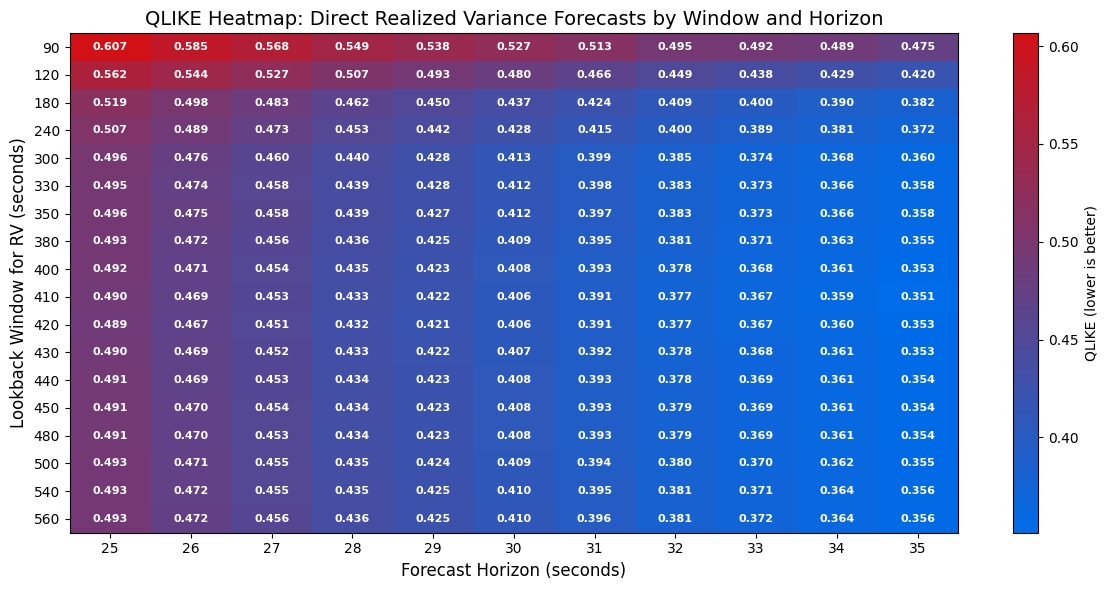

In [12]:
# QLIKE grid: direct RV-window forecasts.
# Rows are the RV lookback window; columns are the target forecast horizon in seconds.
# Each prediction is simply the realized variance over the RV window, with no fitted model.

RV_GRID_WINDOWS = [window for window in RETURN_WINDOWS if 90 <= window <= 560]
TARGET_HORIZONS = list(range(25, 36))
#RV_HEATMAP_TIME_IDS = sorted(train_time_ids)  # training fold only
RV_HEATMAP_TIME_IDS = list(all_time_ids)  # all time_ids

returns_by_time_id = {
    tid: (chunk.sort_values('seconds_in_bucket')['log_price_diff'].dropna().values * 10000)
    for tid, chunk in df.groupby('time_id')
}


def build_single_rv_forecast_frame(returns_lookup, time_ids, rv_window, target_horizon):
    rows = []
    for tid in time_ids:
        returns = returns_lookup.get(tid)
        if returns is None:
            continue

        n = len(returns)
        cutoff = n - target_horizon
        if cutoff < rv_window or target_horizon <= 0:
            continue

        pred_var = float(np.mean(returns[cutoff - rv_window:cutoff] ** 2))
        target_var = float(np.mean(returns[cutoff:] ** 2))
        if np.isfinite(pred_var) and np.isfinite(target_var):
            rows.append({'time_id': tid, 'pred_var': pred_var, 'target_var': target_var})

    return pd.DataFrame(rows)


def qlike_score(realized_var, pred_var):
    pred_var = np.asarray(pred_var, dtype=float)
    realized_var = np.asarray(realized_var, dtype=float)
    finite = np.isfinite(pred_var) & np.isfinite(realized_var)
    if not finite.any():
        return np.nan

    pred_safe = np.maximum(pred_var[finite], EPS)
    realized_safe = np.maximum(realized_var[finite], EPS)
    ratio = realized_safe / pred_safe
    return float(np.mean(ratio - np.log(ratio) - 1))


qlike_grid = pd.DataFrame(index=RV_GRID_WINDOWS, columns=TARGET_HORIZONS, dtype=float)

for rv_window in RV_GRID_WINDOWS:
    for target_horizon in TARGET_HORIZONS:
        forecast_frame = build_single_rv_forecast_frame(
            returns_by_time_id,
            RV_HEATMAP_TIME_IDS,
            rv_window,
            target_horizon,
        )

        if forecast_frame.empty:
            qlike_grid.loc[rv_window, target_horizon] = np.nan
            continue

        qlike_grid.loc[rv_window, target_horizon] = qlike_score(
            forecast_frame['target_var'],
            np.maximum(forecast_frame['pred_var'], EPS),
        )

fig, ax = plt.subplots(figsize=(12, max(6, 0.32 * len(qlike_grid))))

from matplotlib.colors import LinearSegmentedColormap

# Define the custom blue-to-red colormap from #006ce9 to #d21117
custom_cmap = LinearSegmentedColormap.from_list(
    'blue_red_legend',
    ['#006ce9', '#d21117']
)
custom_cmap.set_bad(color='lightgray')

# Calculate minimum and maximum for scaling, ignoring nans
valid_vals = qlike_grid.values[np.isfinite(qlike_grid.values)]
vmin = np.nanmin(valid_vals) if valid_vals.size > 0 else 0
vmax = np.nanmax(valid_vals) if valid_vals.size > 0 else 1

heatmap = ax.imshow(
    np.ma.masked_invalid(qlike_grid.values.astype(float)),
    aspect='auto',
    cmap=custom_cmap,
    vmin=vmin,
    vmax=vmax
)
fig.colorbar(heatmap, ax=ax, label='QLIKE (lower is better)')

ax.set_xticks(np.arange(len(TARGET_HORIZONS)), TARGET_HORIZONS)
ax.set_yticks(np.arange(len(RV_GRID_WINDOWS)), [f'{w}' for w in RV_GRID_WINDOWS])
ax.set_xlabel('Forecast Horizon (seconds)', fontsize=12)
ax.set_ylabel('Lookback Window for RV (seconds)', fontsize=12)
ax.set_title('QLIKE Heatmap: Direct Realized Variance Forecasts by Window and Horizon', fontsize=14)

# Light text coloring: dynamically choose text to be light (e.g., white)
for row_idx, rv_window in enumerate(RV_GRID_WINDOWS):
    for col_idx, target_horizon in enumerate(TARGET_HORIZONS):
        value = qlike_grid.loc[rv_window, target_horizon]
        if np.isfinite(value):
            # Use white text for better contrast over blue/red squares
            ax.text(col_idx, row_idx, f'{value:.3f}', ha='center', va='center', fontsize=8, color='white', fontweight='bold')

plt.tight_layout()
# Make background transparent and save the figure in the images directory as PNG, 500dpi

fig.savefig('images/qlike_grid_heatmap.png', transparent=True, dpi=500)
plt.show()


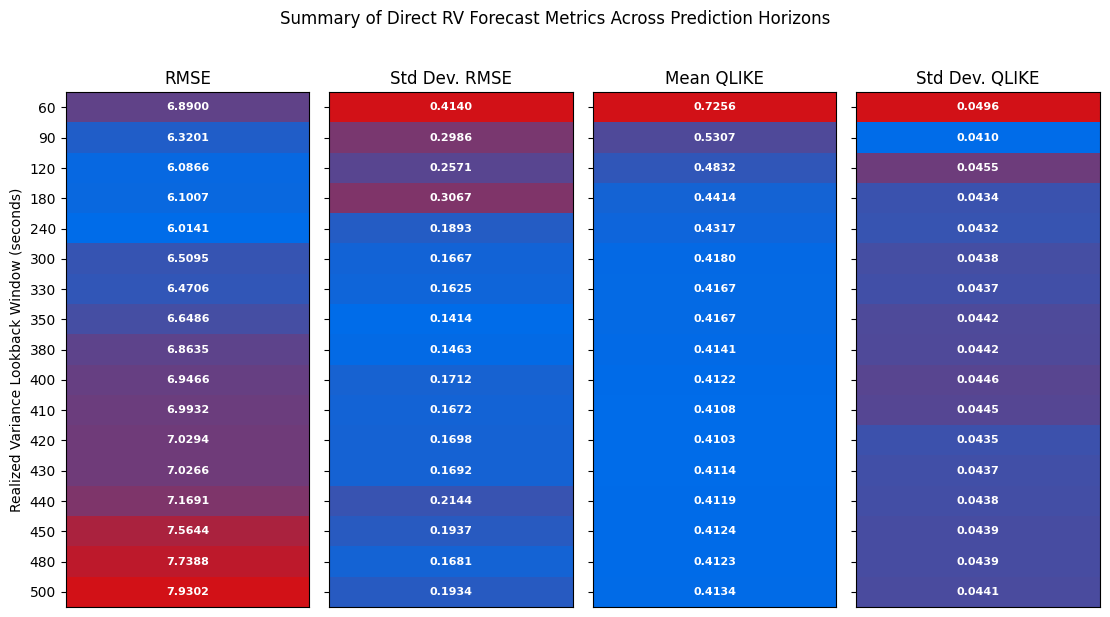

In [13]:
# Heatmap summary for direct RV-window forecasts.
# Uses the same target horizons and first-fold training time_ids as the QLIKE grid, but summarizes each RV window.

from matplotlib.colors import LinearSegmentedColormap

RV_SUMMARY_WINDOWS = [window for window in RETURN_WINDOWS if 60 <= window <= 500]
RV_SUMMARY_HORIZONS = TARGET_HORIZONS

summary_rows = []
for rv_window in RV_SUMMARY_WINDOWS:
    rmse_by_horizon = []
    qlike_by_horizon = []

    for target_horizon in RV_SUMMARY_HORIZONS:
        forecast_frame = build_single_rv_forecast_frame(
            returns_by_time_id,
            RV_HEATMAP_TIME_IDS,
            rv_window,
            target_horizon,
        )

        if forecast_frame.empty:
            continue

        pred = np.maximum(forecast_frame['pred_var'].to_numpy(dtype=float), EPS)
        real = forecast_frame['target_var'].to_numpy(dtype=float)
        finite = np.isfinite(pred) & np.isfinite(real)
        if not finite.any():
            continue

        rmse_by_horizon.append(float(np.sqrt(np.mean((pred[finite] - real[finite]) ** 2))))
        qlike_by_horizon.append(qlike_score(real[finite], pred[finite]))

    summary_rows.append({
        'window': rv_window,
        'mean_RMSE': np.nanmean(rmse_by_horizon) if rmse_by_horizon else np.nan,
        'std_RMSE': np.nanstd(rmse_by_horizon) if rmse_by_horizon else np.nan,
        'mean_QLIKE': np.nanmean(qlike_by_horizon) if qlike_by_horizon else np.nan,
        'std_QLIKE': np.nanstd(qlike_by_horizon) if qlike_by_horizon else np.nan,
    })

rv_metric_summary = pd.DataFrame(summary_rows).set_index('window')

fig, axes = plt.subplots(
    1,
    len(rv_metric_summary.columns),
    figsize=(2.8 * len(rv_metric_summary.columns), max(6, 0.35 * len(rv_metric_summary))),
    sharey=True,
)
if len(rv_metric_summary.columns) == 1:
    axes = [axes]

# Define custom colormap scaling between '#006ce9' (blue) and '#d21117'
custom_cmap = LinearSegmentedColormap.from_list("custom_2color", ['#006ce9', '#d21117'])
custom_cmap.set_bad(color='lightgray')

# Use more proper axis/label naming
for col_idx, (ax, metric) in enumerate(zip(axes, rv_metric_summary.columns)):
    values = rv_metric_summary[[metric]].to_numpy(dtype=float)
    finite_values = values[np.isfinite(values)]
    vmin = np.nanmin(finite_values) if finite_values.size else 0.0
    vmax = np.nanmax(finite_values) if finite_values.size else 1.0
    if vmax <= vmin:
        vmax = vmin + 1.0

    heatmap = ax.imshow(
        np.ma.masked_invalid(values),
        aspect='auto',
        cmap=custom_cmap,
        vmin=vmin,
        vmax=vmax,
    )
    # Improve title: Capitalize and expand abbreviations if appropriate
    if metric == 'mean_RMSE':
        title = 'RMSE'
    elif metric == 'std_RMSE':
        title = 'Std Dev. RMSE'
    elif metric == 'mean_QLIKE':
        title = 'Mean QLIKE'
    elif metric == 'std_QLIKE':
        title = 'Std Dev. QLIKE'
    else:
        title = metric
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks(np.arange(len(rv_metric_summary.index)))
    if col_idx == 0:
        # More descriptive label for y-axis
        ax.set_yticklabels([f'{w}' for w in rv_metric_summary.index])
        ax.set_ylabel('Realized Variance Lookback Window (seconds)')
    else:
        ax.tick_params(axis='y', labelleft=False)

    for row_idx, rv_window in enumerate(rv_metric_summary.index):
        value = rv_metric_summary.loc[rv_window, metric]
        if np.isfinite(value):
            # Set text color to light (for dark backgrounds): white or very pale
            ax.text(0, row_idx, f'{value:.4f}', ha='center', va='center', fontsize=8, color='white', fontweight='bold')

fig.suptitle('Summary of Direct RV Forecast Metrics Across Prediction Horizons', y=1.02)
plt.tight_layout()
fig.savefig('images/rv_metric_summary.png', transparent=True, dpi=500, bbox_inches='tight')
plt.show()

In [14]:
# ── metrics ───────────────────────────────────────────────────────────────────

def compute_metrics(results_df, model_name):
    """Compute scalar out-of-sample evaluation metrics."""
    nan = float('nan')
    empty_metrics = {
        'Model': model_name, 'N': 0, 'MAPE N': 0, 'QLIKE N': 0,
        'MSE': nan, 'RMSE': nan, 'MAE': nan, 'MAPE (%)': nan,
        'Pearson r': nan, 'QLIKE': nan, 'MZ R²': nan,
        'MZ slope': nan, 'MZ intercept': nan,
    }
    if results_df.empty or 'mean_pred_var' not in results_df.columns:
        return empty_metrics

    pred = np.asarray(results_df['mean_pred_var'].values, dtype=float)
    real = np.asarray(results_df['mean_realized_var'].values, dtype=float)
    finite = np.isfinite(pred) & np.isfinite(real)
    pred = pred[finite]
    real = real[finite]
    if len(pred) == 0:
        return empty_metrics

    pred_safe = np.maximum(pred, EPS)
    real_safe = np.maximum(real, EPS)
    mape_mask = real > EPS

    mse  = np.mean((pred - real) ** 2)
    rmse = np.sqrt(mse)
    mae  = np.mean(np.abs(pred - real))
    mape = np.mean(np.abs((pred[mape_mask] - real[mape_mask]) / real[mape_mask])) * 100 if mape_mask.any() else np.nan
    corr = stats.pearsonr(pred, real)[0] if len(pred) > 1 and pred.std() > 0 and real.std() > 0 else np.nan
    ratio = real_safe / pred_safe
    qlike = np.mean(ratio - np.log(ratio) - 1)
    if len(pred) > 1 and pred.std() > 0:
        sl, ic, r, *_ = stats.linregress(pred, real)
    else:
        sl, ic, r = np.nan, np.nan, np.nan

    return {
        'Model'        : model_name,
        'N'            : len(pred),
        'MAPE N'       : int(mape_mask.sum()),
        'QLIKE N'      : len(pred),
        'MSE'          : round(mse,  4),
        'RMSE'         : round(rmse, 4),
        'MAE'          : round(mae,  4),
        'MAPE (%)'     : round(mape, 2),
        'Pearson r'    : round(corr, 4),
        'QLIKE'        : round(qlike, 4),
        'MZ R²'        : round(r**2, 4),
        'MZ slope'     : round(sl,   4),
        'MZ intercept' : round(ic,   4),
    }

# ── GARCH pipeline ────────────────────────────────────────────────────────────

def make_garch_fn(p, q):
    """Return a fit_fn for GARCH(p, q)."""
    def fit_fn(train_ret, horizon):
        mdl = arch_model(train_ret, vol='Garch', p=p, q=q, rescale=False)
        res = mdl.fit(disp='off')
        fc  = res.forecast(horizon=horizon, reindex=False)
        pred_var  = fc.variance.values[-1]
        alpha_sum = sum(res.params.get(f'alpha[{j}]', 0) for j in range(1, p + 1))
        beta_sum  = sum(res.params.get(f'beta[{j}]',  0) for j in range(1, q + 1))
        extra = {
            'omega'       : res.params.get('omega', np.nan),
            'persistence' : alpha_sum + beta_sum,
        }
        return pred_var, extra
    return fit_fn


def run_garch_pipeline(df, garch_configs, test_time_ids, horizon=HORIZON):
    """
    For every time_id:
      - train on returns[0 : n - horizon]
      - forecast `horizon` steps ahead
      - target = mean(returns[n-horizon : n]²)

    Tags each row with is_test so results can be filtered to the
    held-out set for the head-to-head comparison.
    """
    time_ids = df['time_id'].unique()
    buckets  = {cfg['name']: [] for cfg in garch_configs}

    for i, tid in enumerate(time_ids):
        chunk     = df[df['time_id'] == tid].sort_values('seconds_in_bucket')
        returns   = chunk['log_price_diff'].dropna().values * 10000
        n         = len(returns)

        if n < horizon + 10:
            continue

        cutoff    = n - horizon
        train_ret = returns[:cutoff]
        test_ret  = returns[cutoff:]
        real_var  = float(np.mean(test_ret ** 2))

        for cfg in garch_configs:
            try:
                pred_var_arr, extra = cfg['fit_fn'](train_ret, horizon)
                buckets[cfg['name']].append({
                    'time_id'           : tid,
                    'is_test'           : tid in test_time_ids,
                    'mean_pred_var'     : float(np.mean(pred_var_arr)),
                    'mean_realized_var' : real_var,
                    **extra,
                })
            except Exception:
                continue

        if (i + 1) % 500 == 0:
            print(f"  GARCH: {i + 1:,} / {len(time_ids):,} time_ids …")

    _empty = pd.DataFrame({
        'time_id'           : pd.Series(dtype='int64'),
        'is_test'           : pd.Series(dtype='bool'),
        'mean_pred_var'     : pd.Series(dtype='float64'),
        'mean_realized_var' : pd.Series(dtype='float64'),
        'omega'             : pd.Series(dtype='float64'),
        'persistence'       : pd.Series(dtype='float64'),
    })
    return {
        name: pd.DataFrame(rows) if rows else _empty.copy()
        for name, rows in buckets.items()
    }



In [15]:
# ── ML pipeline ───────────────────────────────────────────────────────────────

def run_ml_pipeline_from_features(X_train, y_train, X_test, y_test, test_tids,
                                  ml_configs, default_feature_cols=None):
    """
    Train each supervised model on realized volatility, sqrt(variance), using
    precomputed feature matrices. Predictions are squared back to variance for
    the shared evaluation code.

    Each config can set `feature_cols`; otherwise it uses `default_feature_cols`.
    This lets the full feature matrix be built once and reused across folds.
    """
    results = {}
    fitted_models = {}
    for cfg in ml_configs:
        feature_cols = cfg.get('feature_cols', default_feature_cols)
        if feature_cols is None:
            feature_cols = list(X_train.columns)

        print(f"  Fitting {cfg['name']} on {len(feature_cols):,} features …")
        model = clone(cfg['model'])
        y_train_vol = np.sqrt(np.maximum(y_train.to_numpy(dtype=float), 0.0))
        model.fit(X_train[feature_cols], y_train_vol)

        pred_vol = model.predict(X_test[feature_cols])
        preds = np.maximum(pred_vol, 0.0) ** 2
        results[cfg['name']] = pd.DataFrame({
            'time_id'           : test_tids.values,
            'mean_pred_var'     : preds,
            'mean_pred_vol'     : np.maximum(pred_vol, 0.0),
            'mean_realized_var' : y_test.values,
            'mean_realized_vol' : np.sqrt(np.maximum(y_test.to_numpy(dtype=float), 0.0)),
        })
        fitted_models[cfg['name']] = {
            'model': model,
            'feature_cols': list(feature_cols),
        }

    return results, fitted_models

def make_egarch_fn(p, q):
    """Return a fit_fn for EGARCH(p, q).

    EGARCH models log(σ²) so it naturally captures asymmetric responses to
    positive vs negative shocks (leverage effect).

    Multi-step analytic forecasts are not supported for EGARCH, so simulation
    is used. We use the median across simulation paths rather than the mean to
    guard against the occasional explosive path (β ≈ 1) that would otherwise
    inflate the mean to astronomical values.
    """
    def fit_fn(train_ret, horizon):
        mdl = arch_model(train_ret, vol='EGARCH', p=p, q=q, rescale=False)
        res = mdl.fit(disp='off')
        fc  = res.forecast(horizon=horizon, reindex=False,
                           method='simulation', simulations=500)
        # fc.simulations.variance shape: (1, n_simulations, horizon)
        # Median across paths is robust to the explosive-path problem.
        sim_var  = fc.simulations.variance[0]          # (n_simulations, horizon)
        pred_var = np.nanmedian(sim_var, axis=0)        # (horizon,)
        extra = {
            'omega'       : res.params.get('omega', np.nan),
            'persistence' : np.nan,  # not directly interpretable in EGARCH
        }
        return pred_var, extra
    return fit_fn


def make_gjr_garch_fn(p, q):
    """Return a fit_fn for GJR-GARCH(p, o=1, q).

    GJR-GARCH adds a separate coefficient for negative return shocks,
    allowing bad news to increase volatility more than good news.
    """
    def fit_fn(train_ret, horizon):
        mdl = arch_model(train_ret, vol='GARCH', p=p, o=1, q=q, rescale=False)
        res = mdl.fit(disp='off')
        fc  = res.forecast(horizon=horizon, reindex=False)
        pred_var  = fc.variance.values[-1]
        alpha_sum = sum(res.params.get(f'alpha[{j}]', 0) for j in range(1, p + 1))
        gamma     = res.params.get('gamma[1]', 0)   # asymmetry term
        beta_sum  = sum(res.params.get(f'beta[{j}]',  0) for j in range(1, q + 1))
        extra = {
            'omega'       : res.params.get('omega', np.nan),
            'persistence' : alpha_sum + 0.5 * gamma + beta_sum,
        }
        return pred_var, extra
    return fit_fn

def make_riskmetrics_fn(lam=0.94):
    """Return a fit_fn for RiskMetrics (EWMA, λ=0.94).

    No parameters are estimated — variance is tracked as a rolling EWMA
    of squared returns.  The h-step-ahead forecast is flat at the current
    EWMA level (random-walk-in-variance assumption).  Useful as a
    no-estimation baseline against the fitted GARCH models.
    """
    alpha = 1.0 - lam

    def fit_fn(train_ret, horizon):
        r2       = train_ret ** 2
        ewma_var = float(pd.Series(r2).ewm(alpha=alpha, adjust=False).mean().iloc[-1])
        pred_var = np.full(horizon, ewma_var)   # flat forecast
        extra    = {'omega': np.nan, 'persistence': lam}
        return pred_var, extra
    return fit_fn

In [16]:
# ── model registry ────────────────────────────────────────────────────────────

garch_configs = [
    {'name': 'GARCH(1,1)',    'fit_fn': make_garch_fn(1, 1)},
    {'name': 'GARCH(3,3)',    'fit_fn': make_garch_fn(3, 3)},
    {'name': 'GJR-GARCH(1,1)', 'fit_fn': make_gjr_garch_fn(1, 1)},
]

# HAR-RV remains as a simple four-feature benchmark.
# The two-RV linear model asks whether the two strongest direct-RV windows
# are enough to predict volatility without the full engineered feature set.
# The other ML models below use the full engineered feature set.
_HAR_COLS = ['RV_30', 'RV_60', 'RV_120', 'RV_240', 'RV_300', 'RV_420', 'RV_500']
_RV_350_420_COLS = ['RV_350', 'RV_420']

# Direct realised-variance benchmarks: no fitting, just use the chosen RV window
# as the variance forecast.
direct_rv_configs = [
    {'name': 'Direct RV_240', 'feature_col': 'RV_240'},
    {'name': 'Direct RV_300', 'feature_col': 'RV_300'},
    {'name': 'Direct RV_500', 'feature_col': 'RV_350'},
    {'name': 'Direct RV_420', 'feature_col': 'RV_420'},
]

ml_configs = [
    {
        'name'        : 'HAR-RV',
        'model'       : LinearRegression(),
        'feature_cols': _HAR_COLS,
    },
    {
        'name'        : 'RV_350_420 Linear Regression',
        'model'       : Pipeline([('scaler', StandardScaler()), ('reg', LinearRegression())]),
        'feature_cols': _RV_350_420_COLS,
    },
    {
        'name'  : 'Linear Regression',
        'model' : Pipeline([('scaler', StandardScaler()), ('reg', LinearRegression())]),
    },
    {
        'name'  : 'Ridge Regression',
        'model' : Pipeline([('scaler', StandardScaler()), ('reg', RidgeCV(alphas=np.logspace(-4, 4, 25)))]),
    },
    {
        'name'  : 'LASSO',
        'model' : Pipeline([('scaler', StandardScaler()), ('reg', Lasso(alpha=0.01, max_iter=5000))]),
    },
    {
        'name'  : 'Decision Tree',
        'model' : DecisionTreeRegressor(max_depth=6, min_samples_leaf=20, random_state=42),
    },
    {
        'name'  : 'Random Forest',
        'model' : RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42),
    },
    {
        'name'  : 'XGBoost',
        'model' : xgb.XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=4,
                                    subsample=0.8, colsample_bytree=0.8,
                                    random_state=42, n_jobs=-1),
    },
]


In [17]:
# ── run 5-fold cross-validation ───────────────────────────────────────────────

print("=" * 60)
print(f"Running GARCH pipeline once on all {len(all_time_ids):,} time_ids …")
print("=" * 60)
garch_results = run_garch_pipeline(df, garch_configs, set(all_time_ids))
print()
for name, res in garch_results.items():
    print(f"  {name}: {len(res):,} total predictions")

cv_results_parts = {name: [] for name in garch_results.keys()}
cv_results_parts.update({cfg['name']: [] for cfg in direct_rv_configs})
cv_results_parts.update({cfg['name']: [] for cfg in ml_configs})
cv_metrics_rows = []
fitted_ml_models = {}

for split in cv_splits:
    fold = split['fold']
    train_ids = split['train_ids']
    test_ids = split['test_ids']

    train_mask = all_feature_tids.isin(train_ids).values
    test_mask = all_feature_tids.isin(test_ids).values

    X_train_fold = X_all_full.iloc[train_mask]
    y_train_fold = y_all.iloc[train_mask]
    X_test_fold = X_all_full.iloc[test_mask]
    y_test_fold = y_all.iloc[test_mask]
    test_tids_fold = all_feature_tids.iloc[test_mask]

    print()
    print("=" * 60)
    print(
        f"Fold {fold}/{N_FOLDS}: "
        f"train={len(X_train_fold):,}, test={len(X_test_fold):,} samples"
    )
    print("=" * 60)

    for name, res in garch_results.items():
        fold_res = res[res['time_id'].isin(test_ids)].copy()
        fold_res['fold'] = fold
        cv_results_parts[name].append(fold_res)
        cv_metrics_rows.append({
            'Fold': fold,
            **compute_metrics(fold_res, name),
        })

    for cfg in direct_rv_configs:
        col = cfg['feature_col']
        fold_res = pd.DataFrame({
            'time_id': test_tids_fold.values,
            'fold': fold,
            'mean_pred_var': X_test_fold[col].to_numpy(dtype=float),
            'mean_realized_var': y_test_fold.to_numpy(dtype=float),
        }).dropna(subset=['mean_pred_var', 'mean_realized_var'])
        cv_results_parts[cfg['name']].append(fold_res)
        cv_metrics_rows.append({
            'Fold': fold,
            **compute_metrics(fold_res, cfg['name']),
        })

    fold_ml_results, fold_fitted_models = run_ml_pipeline_from_features(
        X_train_fold, y_train_fold,
        X_test_fold, y_test_fold, test_tids_fold,
        ml_configs,
        default_feature_cols=FEATURE_COLS,
    )
    fitted_ml_models = fold_fitted_models

    for name, res in fold_ml_results.items():
        fold_res = res.copy()
        fold_res['fold'] = fold
        cv_results_parts[name].append(fold_res)
        cv_metrics_rows.append({
            'Fold': fold,
            **compute_metrics(fold_res, name),
        })

cv_results_by_model = {
    name: pd.concat(parts, ignore_index=True) if parts else pd.DataFrame()
    for name, parts in cv_results_parts.items()
}
direct_rv_results = {cfg['name']: cv_results_by_model[cfg['name']] for cfg in direct_rv_configs}
ml_results = {cfg['name']: cv_results_by_model[cfg['name']] for cfg in ml_configs}
all_results_test = cv_results_by_model
cv_metrics_df = pd.DataFrame(cv_metrics_rows)

print()
print("5-fold cross-validation complete")
for name, res in all_results_test.items():
    print(f"  {name}: {len(res):,} held-out predictions")


Running GARCH pipeline once on all 3,830 time_ids …


/var/folders/yr/skjwcgyn0d90_vjgw9zsp_4w0000gn/T/ipykernel_1688/2713916575.py:77: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  res = mdl.fit(disp='off')
/var/folders/yr/skjwcgyn0d90_vjgw9zsp_4w0000gn/T/ipykernel_1688/2713916575.py:77: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  res = mdl.fit(disp='off')


  GARCH: 500 / 3,830 time_ids …


/var/folders/yr/skjwcgyn0d90_vjgw9zsp_4w0000gn/T/ipykernel_1688/2713916575.py:77: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  res = mdl.fit(disp='off')
/var/folders/yr/skjwcgyn0d90_vjgw9zsp_4w0000gn/T/ipykernel_1688/2713916575.py:77: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  res = mdl.fit(disp='off')


  GARCH: 1,000 / 3,830 time_ids …


...

  GARCH: 2,500 / 3,830 time_ids …


/var/folders/yr/skjwcgyn0d90_vjgw9zsp_4w0000gn/T/ipykernel_1688/2713916575.py:77: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  res = mdl.fit(disp='off')
/var/folders/yr/skjwcgyn0d90_vjgw9zsp_4w0000gn/T/ipykernel_1688/2713916575.py:77: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  res = mdl.fit(disp='off')
/var/folders/yr/skjwcgyn0d90_vjgw9zsp_4w0000gn/T/ipykernel_1688/2713916575.py:77: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  res = mdl.fit(disp='off')


  GARCH: 3,000 / 3,830 time_ids …


/var/folders/yr/skjwcgyn0d90_vjgw9zsp_4w0000gn/T/ipykernel_1688/2713916575.py:77: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  res = mdl.fit(disp='off')


  GARCH: 3,500 / 3,830 time_ids …

  GARCH(1,1): 3,830 total predictions
  GARCH(3,3): 3,830 total predictions
  GJR-GARCH(1,1): 3,830 total predictions

Fold 1/5: train=3,064, test=766 samples
  Fitting HAR-RV on 7 features …
  Fitting RV_350_420 Linear Regression on 2 features …
  Fitting Linear Regression on 346 features …
  Fitting Ridge Regression on 346 features …
  Fitting LASSO on 346 features …
  Fitting Decision Tree on 346 features …
  Fitting Random Forest on 346 features …
  Fitting XGBoost on 346 features …

Fold 2/5: train=3,064, test=766 samples
  Fitting HAR-RV on 7 features …
  Fitting RV_350_420 Linear Regression on 2 features …
  Fitting Linear Regression on 346 features …
  Fitting Ridge Regression on 346 features …
  Fitting LASSO on 346 features …
  Fitting Decision Tree on 346 features …
  Fitting Random Forest on 346 features …
  Fitting XGBoost on 346 features …

Fold 3/5: train=3,064, test=766 samples
  Fitting HAR-RV on 7 features …
  Fitting RV_350_420 Line

In [18]:
# Combined held-out predictions from the 5-fold cross-validation run.
all_results_test = cv_results_by_model


In [19]:
print("=" * 70)
print("Head-to-Head Comparison — 5-Fold Cross-Validation")
print("=" * 70)
test_metrics_rows = [compute_metrics(res_df, name) for name, res_df in all_results_test.items()]
test_comparison_df = pd.DataFrame(test_metrics_rows).set_index('Model')
with pd.option_context('display.float_format', '{:,.4f}'.format):
    display(test_comparison_df.T)

print()
print("=" * 70)
print("Per-Fold Metrics")
print("=" * 70)
with pd.option_context('display.float_format', '{:,.4f}'.format):
    display(cv_metrics_df.set_index(['Fold', 'Model']).sort_index())

print()
print("=" * 70)
print("GARCH — Full Dataset Performance (all time_ids)")
print("=" * 70)
garch_full_rows = [compute_metrics(res_df, name) for name, res_df in garch_results.items()]
garch_full_df = pd.DataFrame(garch_full_rows).set_index('Model')
with pd.option_context('display.float_format', '{:,.4f}'.format):
    display(garch_full_df.T)

# Feature importance for interpretable ML models from the final CV fold.
print()
print("=" * 70)
print("Feature Importances — Final CV Fold")
print("=" * 70)

for name, fitted in fitted_ml_models.items():
    model = fitted['model']
    configured_features = fitted['feature_cols']

    # Extract the underlying estimator from Pipeline if needed
    estimator = model.named_steps['reg'] if hasattr(model, 'named_steps') else model

    if hasattr(estimator, 'coef_'):
        importances = np.abs(estimator.coef_)
        label = 'Coefficient |magnitude|'
    elif hasattr(estimator, 'feature_importances_'):
        importances = estimator.feature_importances_
        label = 'Feature Importance'
    else:
        continue

    if len(importances) == len(configured_features):
        importance_index = configured_features
    elif name == 'HAR-RV':
        importance_index = _HAR_COLS
    elif len(importances) == len(FEATURE_COLS):
        importance_index = FEATURE_COLS
    else:
        importance_index = [f'feature_{i}' for i in range(len(importances))]

    fi_df = pd.Series(importances, index=importance_index).sort_values(ascending=False)
    print()
    print(f"{name}  ({label})")
    display(fi_df.to_frame(label))


Head-to-Head Comparison — 5-Fold Cross-Validation


Model,"GARCH(1,1)","GARCH(3,3)","GJR-GARCH(1,1)",Direct RV_240,Direct RV_300,Direct RV_500,Direct RV_420,HAR-RV,RV_350_420 Linear Regression,Linear Regression,Ridge Regression,LASSO,Decision Tree,Random Forest,XGBoost
N,"3,830.0000","3,830.0000","3,830.0000","3,830.0000","3,830.0000","3,830.0000","3,830.0000","3,830.0000","3,830.0000","3,830.0000","3,830.0000","3,830.0000","3,830.0000","3,830.0000","3,830.0000"
MAPE N,"3,830.0000","3,830.0000","3,830.0000","3,830.0000","3,830.0000","3,830.0000","3,830.0000","3,830.0000","3,830.0000","3,830.0000","3,830.0000","3,830.0000","3,830.0000","3,830.0000","3,830.0000"
QLIKE N,"3,830.0000","3,830.0000","3,830.0000","3,830.0000","3,830.0000","3,830.0000","3,830.0000","3,830.0000","3,830.0000","3,830.0000","3,830.0000","3,830.0000","3,830.0000","3,830.0000","3,830.0000"
MSE,46.0664,77.1552,45.3955,35.1415,42.0046,43.6480,49.8897,359.9562,130.0147,72.6404,35.2804,35.7795,40.6088,36.7253,35.4852
RMSE,6.7872,8.7838,6.7376,5.9280,6.4811,6.6067,7.0633,18.9725,11.4024,8.5229,5.9397,5.9816,6.3725,6.0601,5.9569
MAE,2.6483,2.7309,2.6636,2.3353,2.3799,2.3955,2.4438,2.8353,2.7709,2.4518,2.1409,2.1534,2.3705,2.1899,2.1875
MAPE (%),"20,167.5600","20,519.6200","20,114.8200","12,500.3900","15,451.2700","15,539.5700","21,219.8800","125,606.9600","159,516.3300","56,641.3300","31,172.7900","29,358.5000","11,033.1500","26,217.0800","24,463.4700"
Pearson r,0.6884,0.6395,0.6907,0.7392,0.7122,0.7067,0.6947,0.3966,0.4722,0.5939,0.7204,0.7167,0.6682,0.7080,0.7211
QLIKE,0.4328,0.4424,0.4313,0.4283,0.4131,0.4116,0.4057,0.5065,0.5538,"28,046,691.2706","642,312.1016",0.4522,0.4886,0.4235,0.4370
MZ R²,0.4739,0.4090,0.4771,0.5464,0.5072,0.4994,0.4827,0.1573,0.2230,0.3527,0.5190,0.5136,0.4464,0.5012,0.5199



Per-Fold Metrics


N  MAPE N  QLIKE N     MSE   RMSE    MAE  \
Fold Model                                                                      
1    Decision Tree                 766     766      766 77.3947 8.7974 2.6515   
     Direct RV_240                 766     766      766 53.6585 7.3252 2.4476   
     Direct RV_300                 766     766      766 59.8369 7.7354 2.5524   
     Direct RV_420                 766     766      766 72.1236 8.4926 2.6507   
     Direct RV_500                 766     766      766 57.0530 7.5533 2.5748   
...                                ...     ...      ...     ...    ...    ...   
5    Linear Regression             766     766      766 48.6078 6.9719 2.0715   
     RV_350_420 Linear Regression  766     766      766 14.1432 3.7607 2.1023   
     Random Forest                 766     766      766 10.6566 3.2644 1.7944   
     Ridge Regression              766     766      766 11.2833 3.3591 1.7321   
     XGBoost                       766     766      766 10.2202 3.1969 1.7862   

                                      MAPE (%)  Pearson r        QLIKE  MZ R²  \
Fold Model                                                                      
1    Decision Tree                    259.2100     0.6681       0.4899 0.4464   
     Direct RV_240                    296.1000     0.7928       0.4403 0.6285   
     Direct RV_300                    319.5300     0.7451       0.4223 0.5551   
     Direct RV_420                    347.3000     0.7130       0.4157 0.5084   
     Direct RV_500                    330.3800     0.7599       0.4186 0.5775   
...                                        ...        ...          ...    ...   
5    Linear Regression            279,089.5000     0.4510 241,959.1944 0.2034   
     RV_350_420 Linear Regression 785,504.1200     0.7012       0.5123 0.4917   
     Random Forest                125,645.3400     0.7500       0.4109 0.5626   
     Ridge Regression             151,597.1000     0.7405       0.4178 0.5484   
     XGBoost                      117,051.9400     0.7704       0.4260 0.5935   

                                   MZ slope  MZ intercept  
Fold Model                                                 
1    Decision Tree                   1.3059       -0.6680  
     Direct RV_240                   1.2816       -1.3309  
     Direct RV_300                   0.9344        0.0151  
     Direct RV_420                   0.7670        0.6119  
     Direct RV_500                   0.9248       -0.0229  
...                                     ...           ...  
5    Linear Regression               0.2900        2.4038  
     RV_350_420 Linear Regression    1.4996       -0.5672  
     Random Forest                   0.9259        0.3813  
     Ridge Regression                0.8602        0.6506  
     XGBoost                         0.8579        0.6129  

[75 rows x 12 columns]


GARCH — Full Dataset Performance (all time_ids)


...

,Feature Importance
RV_430,0.655170
mean_abs_ret_410,0.163144
vol_330,0.067146
mean_abs_ret_120,0.019532
EWMA_094,0.012353
...,...
downside_RV_300,0.000000
prop_zero_ret_300,0.000000
max_abs_ret_300,0.000000
mean_ret_300,0.000000



Random Forest  (Feature Importance)


,Feature Importance
vol_400,0.047421
RV_400,0.042530
vol_430,0.027492
RV_430,0.022382
mean_abs_ret_350,0.022312
...,...
jump_count_20,0.000116
jump_count_5,0.000013
n_obs,0.000000
cutoff,0.000000



XGBoost  (Feature Importance)


,Feature Importance
vol_440,0.141382
RV_440,0.096635
RV_560,0.072624
mean_abs_ret_480,0.063629
RV_430,0.046520
...,...
vol_350,0.000000
upside_RV_400,0.000000
prop_zero_ret_410,0.000000
n_obs,0.000000


In [20]:
# Stacking: use the GJR-GARCH forecast as extra supervised-model features.
# This asks whether the order-book/RV features add information while still
# letting the model learn how much to trust GJR-GARCH.

STACK_BASELINE_GARCH_MODEL = 'GJR-GARCH(1,1)'

stacked_model_configs = [
    {
        'name': f'{STACK_BASELINE_GARCH_MODEL} stacked Linear Regression',
        'model': Pipeline([
            ('scaler', StandardScaler()),
            ('reg', LinearRegression()),
        ]),
    },
    {
        'name': f'{STACK_BASELINE_GARCH_MODEL} stacked Ridge Regression',
        'model': Pipeline([
            ('scaler', StandardScaler()),
            ('reg', RidgeCV(alphas=np.logspace(-4, 4, 25))),
        ]),
    },
    {
        'name': f'{STACK_BASELINE_GARCH_MODEL} stacked LASSO',
        'model': Pipeline([
            ('scaler', StandardScaler()),
            ('reg', Lasso(alpha=0.01, max_iter=5000)),
        ]),
    },
    {
        'name': f'{STACK_BASELINE_GARCH_MODEL} stacked Decision Tree',
        'model': DecisionTreeRegressor(max_depth=6, min_samples_leaf=20, random_state=42),
    },
    {
        'name': f'{STACK_BASELINE_GARCH_MODEL} stacked Random Forest',
        'model': RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42),
    },
    {
        'name': f'{STACK_BASELINE_GARCH_MODEL} stacked XGBoost',
        'model': xgb.XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=4,
                                  subsample=0.8, colsample_bytree=0.8,
                                  random_state=42, n_jobs=-1),
    },
]

stack_feature_frame = X_all_full.copy()
stack_feature_frame['time_id'] = all_feature_tids.values
stack_feature_frame['target_var'] = y_all.values

stack_gjr_features = (
    garch_results[STACK_BASELINE_GARCH_MODEL]
    [['time_id', 'mean_pred_var']]
    .rename(columns={'mean_pred_var': 'gjr_pred_var'})
)

stack_feature_frame = stack_feature_frame.merge(stack_gjr_features, on='time_id', how='inner')
stack_feature_frame['sqrt_gjr_pred_var'] = np.sqrt(np.maximum(stack_feature_frame['gjr_pred_var'], 0.0))
stack_feature_frame['log_gjr_pred_var'] = np.log(np.maximum(stack_feature_frame['gjr_pred_var'], EPS))

STACK_GJR_FEATURE_COLS = ['gjr_pred_var', 'sqrt_gjr_pred_var', 'log_gjr_pred_var']
STACKED_FEATURE_COLS = FEATURE_COLS + STACK_GJR_FEATURE_COLS

stacked_cv_parts = {cfg['name']: [] for cfg in stacked_model_configs}
stacked_cv_metrics_rows = []
fitted_stacked_models = {}

for split in cv_splits:
    fold = split['fold']
    train_ids = split['train_ids']
    test_ids = split['test_ids']

    train_frame = stack_feature_frame[stack_feature_frame['time_id'].isin(train_ids)].copy()
    test_frame = stack_feature_frame[stack_feature_frame['time_id'].isin(test_ids)].copy()

    if train_frame.empty or test_frame.empty:
        continue

    X_train_stack = train_frame[STACKED_FEATURE_COLS]
    y_train_stack_vol = np.sqrt(np.maximum(train_frame['target_var'].to_numpy(dtype=float), 0.0))
    X_test_stack = test_frame[STACKED_FEATURE_COLS]

    for cfg in stacked_model_configs:
        model = clone(cfg['model'])
        model.fit(X_train_stack, y_train_stack_vol)
        pred_vol = np.maximum(model.predict(X_test_stack), 0.0)
        pred_var = pred_vol ** 2

        fold_results = pd.DataFrame({
            'time_id': test_frame['time_id'].values,
            'fold': fold,
            'gjr_pred_var': test_frame['gjr_pred_var'].values,
            'mean_pred_var': pred_var,
            'mean_pred_vol': pred_vol,
            'mean_realized_var': test_frame['target_var'].values,
            'mean_realized_vol': np.sqrt(np.maximum(test_frame['target_var'].to_numpy(dtype=float), 0.0)),
        })
        stacked_cv_parts[cfg['name']].append(fold_results)
        stacked_cv_metrics_rows.append({
            'Fold': fold,
            **compute_metrics(fold_results, cfg['name']),
        })
        fitted_stacked_models[cfg['name']] = model

stacked_results_by_model = {
    name: pd.concat(parts, ignore_index=True) if parts else pd.DataFrame()
    for name, parts in stacked_cv_parts.items()
}
stacked_metrics_df = pd.DataFrame(stacked_cv_metrics_rows)

all_results_with_stacked = {**all_results_test, **stacked_results_by_model}
stacked_comparison_df = pd.DataFrame(
    [compute_metrics(res_df, name) for name, res_df in all_results_with_stacked.items()]
).set_index('Model')

print('=' * 70)
print('Head-to-Head Comparison — Including GJR Stacked Models')
print('=' * 70)
with pd.option_context('display.float_format', '{:,.4f}'.format):
    display(stacked_comparison_df.T)

print()
print('=' * 70)
print('GJR Stacked Model Per-Fold Metrics')
print('=' * 70)
with pd.option_context('display.float_format', '{:,.4f}'.format):
    display(stacked_metrics_df.set_index(['Fold', 'Model']).sort_index())


Head-to-Head Comparison — Including GJR Stacked Models


Model,"GARCH(1,1)","GARCH(3,3)","GJR-GARCH(1,1)",Direct RV_240,Direct RV_300,Direct RV_500,Direct RV_420,HAR-RV,RV_350_420 Linear Regression,Linear Regression,...,LASSO,Decision Tree,Random Forest,XGBoost,"GJR-GARCH(1,1) stacked Linear Regression","GJR-GARCH(1,1) stacked Ridge Regression","GJR-GARCH(1,1) stacked LASSO","GJR-GARCH(1,1) stacked Decision Tree","GJR-GARCH(1,1) stacked Random Forest","GJR-GARCH(1,1) stacked XGBoost"
N,"3,830.0000","3,830.0000","3,830.0000","3,830.0000","3,830.0000","3,830.0000","3,830.0000","3,830.0000","3,830.0000","3,830.0000",...,"3,830.0000","3,830.0000","3,830.0000","3,830.0000","3,830.0000","3,830.0000","3,830.0000","3,830.0000","3,830.0000","3,830.0000"
MAPE N,"3,830.0000","3,830.0000","3,830.0000","3,830.0000","3,830.0000","3,830.0000","3,830.0000","3,830.0000","3,830.0000","3,830.0000",...,"3,830.0000","3,830.0000","3,830.0000","3,830.0000","3,830.0000","3,830.0000","3,830.0000","3,830.0000","3,830.0000","3,830.0000"
QLIKE N,"3,830.0000","3,830.0000","3,830.0000","3,830.0000","3,830.0000","3,830.0000","3,830.0000","3,830.0000","3,830.0000","3,830.0000",...,"3,830.0000","3,830.0000","3,830.0000","3,830.0000","3,830.0000","3,830.0000","3,830.0000","3,830.0000","3,830.0000","3,830.0000"
MSE,46.0664,77.1552,45.3955,35.1415,42.0046,43.6480,49.8897,359.9562,130.0147,72.6404,...,35.7795,40.6088,36.7253,35.4852,91.3688,35.2868,36.9786,40.6490,36.5599,35.0031
RMSE,6.7872,8.7838,6.7376,5.9280,6.4811,6.6067,7.0633,18.9725,11.4024,8.5229,...,5.9816,6.3725,6.0601,5.9569,9.5587,5.9403,6.0810,6.3757,6.0465,5.9163
MAE,2.6483,2.7309,2.6636,2.3353,2.3799,2.3955,2.4438,2.8353,2.7709,2.4518,...,2.1534,2.3705,2.1899,2.1875,2.4876,2.1419,2.1600,2.3782,2.1935,2.1781
MAPE (%),"20,167.5600","20,519.6200","20,114.8200","12,500.3900","15,451.2700","15,539.5700","21,219.8800","125,606.9600","159,516.3300","56,641.3300",...,"29,358.5000","11,033.1500","26,217.0800","24,463.4700","49,732.9000","28,643.4800","23,722.8500","10,930.6300","27,663.6400","23,633.6900"
Pearson r,0.6884,0.6395,0.6907,0.7392,0.7122,0.7067,0.6947,0.3966,0.4722,0.5939,...,0.7167,0.6682,0.7080,0.7211,0.5625,0.7204,0.7068,0.6678,0.7099,0.7248
QLIKE,0.4328,0.4424,0.4313,0.4283,0.4131,0.4116,0.4057,0.5065,0.5538,"28,046,691.2706",...,0.4522,0.4886,0.4235,0.4370,"28,046,691.1787","642,312.1009",0.5004,0.4867,0.4254,0.4337
MZ R²,0.4739,0.4090,0.4771,0.5464,0.5072,0.4994,0.4827,0.1573,0.2230,0.3527,...,0.5136,0.4464,0.5012,0.5199,0.3164,0.5190,0.4996,0.4459,0.5040,0.5253



GJR Stacked Model Per-Fold Metrics


N  MAPE N  QLIKE N      MSE  \
Fold Model                                                                     
1    GJR-GARCH(1,1) stacked Decision Tree      766     766      766  77.5456   
     GJR-GARCH(1,1) stacked LASSO              766     766      766  66.4922   
     GJR-GARCH(1,1) stacked Linear Regression  766     766      766 288.6542   
     GJR-GARCH(1,1) stacked Random Forest      766     766      766  72.1151   
     GJR-GARCH(1,1) stacked Ridge Regression   766     766      766  68.3723   
     GJR-GARCH(1,1) stacked XGBoost            766     766      766  73.2855   
2    GJR-GARCH(1,1) stacked Decision Tree      766     766      766  33.7485   
     GJR-GARCH(1,1) stacked LASSO              766     766      766  18.3179   
     GJR-GARCH(1,1) stacked Linear Regression  766     766      766  45.2405   
     GJR-GARCH(1,1) stacked Random Forest      766     766      766  27.2371   
     GJR-GARCH(1,1) stacked Ridge Regression   766     766      766  24.5259   
     GJR-GARCH(1,1) stacked XGBoost            766     766      766  23.8266   
3    GJR-GARCH(1,1) stacked Decision Tree      766     766      766  56.2521   
     GJR-GARCH(1,1) stacked LASSO              766     766      766  66.6174   
     GJR-GARCH(1,1) stacked Linear Regression  766     766      766  41.3098   
     GJR-GARCH(1,1) stacked Random Forest      766     766      766  51.0251   
     GJR-GARCH(1,1) stacked Ridge Regression   766     766      766  52.3397   
     GJR-GARCH(1,1) stacked XGBoost            766     766      766  44.8435   
4    GJR-GARCH(1,1) stacked Decision Tree      766     766      766  24.2621   
     GJR-GARCH(1,1) stacked LASSO              766     766      766  22.3514   
     GJR-GARCH(1,1) stacked Linear Regression  766     766      766  29.9599   
     GJR-GARCH(1,1) stacked Random Forest      766     766      766  21.9999   
     GJR-GARCH(1,1) stacked Ridge Regression   766     766      766  20.2609   
     GJR-GARCH(1,1) stacked XGBoost            766     766      766  22.7589   
5    GJR-GARCH(1,1) stacked Decision Tree      766     766      766  11.4368   
     GJR-GARCH(1,1) stacked LASSO              766     766      766  11.1141   
     GJR-GARCH(1,1) stacked Linear Regression  766     766      766  51.6795   
     GJR-GARCH(1,1) stacked Random Forest      766     766      766  10.4222   
     GJR-GARCH(1,1) stacked Ridge Regression   766     766      766  10.9354   
     GJR-GARCH(1,1) stacked XGBoost            766     766      766  10.3012   

                                                 RMSE    MAE     MAPE (%)  \
Fold Model                                                                  
1    GJR-GARCH(1,1) stacked Decision Tree      8.8060 2.6890     261.7600   
     GJR-GARCH(1,1) stacked LASSO              8.1543 2.3085     234.8000   
     GJR-GARCH(1,1) stacked Linear Regression 16.9898 2.9097     278.8900   
     GJR-GARCH(1,1) stacked Random Forest      8.4921 2.3594     259.9400   
     GJR-GARCH(1,1) stacked Ridge Regression   8.2688 2.3011     245.1500   
     GJR-GARCH(1,1) stacked XGBoost            8.5607 2.3520     277.4500   
2    GJR-GARCH(1,1) stacked Decision Tree      5.8093 2.4170     268.3500   
     GJR-GARCH(1,1) stacked LASSO              4.2799 2.0473     260.5300   
     GJR-GARCH(1,1) stacked Linear Regression  6.7261 2.3415     253.9600   
     GJR-GARCH(1,1) stacked Random Forest      5.2189 2.1550     300.5400   
     GJR-GARCH(1,1) stacked Ridge Regression   4.9524 2.0760     269.3600   
     GJR-GARCH(1,1) stacked XGBoost            4.8812 2.1305     276.9000   
3    GJR-GARCH(1,1) stacked Decision Tree      7.5001 2.6884   2,152.1000   
     GJR-GARCH(1,1) stacked LASSO              8.1619 2.5949   1,741.6400   
     GJR-GARCH(1,1) stacked Linear Regression  6.4273 2.6606   1,970.9300   
     GJR-GARCH(1,1) stacked Random Forest      7.1432 2.4979   2,549.1500   
     GJR-GARCH(1,1) stacked Ridge Regression   7.2346 2.5334   1,922.5700   
     GJR-GARCH(1,1) stack

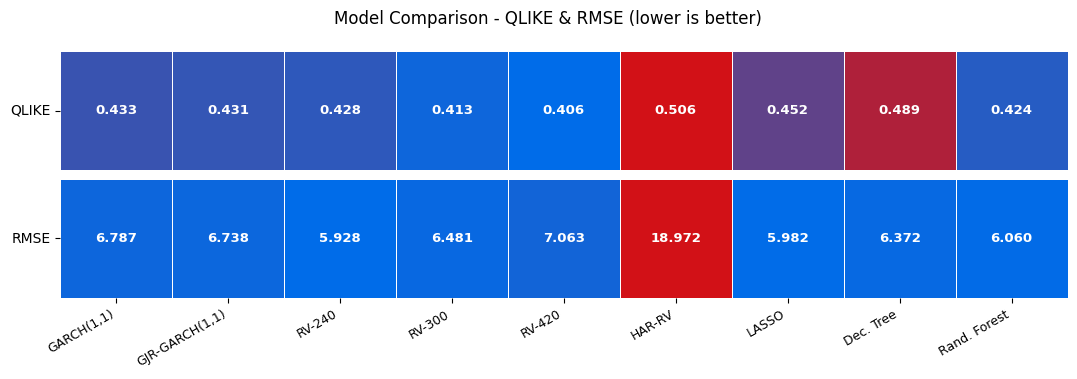

In [21]:

# ── Head-to-Head Heatmap — QLIKE & RMSE ──────────────────────────────────────

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors


# Ordered list of (notebook model name → display label)
HEATMAP_MODEL_MAP = [
    ('GARCH(1,1)',        'GARCH(1,1)'),
    ('GJR-GARCH(1,1)',    'GJR-GARCH(1,1)'),
    ('Direct RV_240',    'RV-240'),
    ('Direct RV_300',    'RV-300'),
    ('Direct RV_350',    'RV-350'),   # feature_col='RV_350'
    ('Direct RV_420',    'RV-420'),
    ('HAR-RV',           'HAR-RV'),
    ('LASSO',            'LASSO'),
    ('Decision Tree',    'Dec. Tree'),
    ('Random Forest',    'Rand. Forest'),
]

heatmap_rows = []
for orig_name, display_name in HEATMAP_MODEL_MAP:
    src = all_results_test if orig_name in all_results_test else garch_results
    if orig_name not in src:
        continue
    m = compute_metrics(src[orig_name], orig_name)
    heatmap_rows.append({
        'Model': display_name,
        'QLIKE': round(m['QLIKE'], 3),
        'RMSE':  round(m['RMSE'],  3),
    })

heatmap_df = pd.DataFrame(heatmap_rows).set_index('Model')
# Rows = metrics, columns = models
heat_T = heatmap_df[['QLIKE', 'RMSE']].T

fig, axes = plt.subplots(
    2, 1,
    figsize=(13, 3.2),
    gridspec_kw={'hspace': 0.08},
)

for ax, metric in zip(axes, ['QLIKE', 'RMSE']):
    row = heat_T.loc[[metric]]
    vmin, vmax = row.values.min(), row.values.max()
    sns.heatmap(
        row,
        ax=ax,
        cmap=mcolors.LinearSegmentedColormap.from_list('custom', ['#006ce9', '#d21117']),
        vmin=vmin,
        vmax=vmax,
        annot=True,
        fmt='.3f',  # Changed to 3 decimal places
        linewidths=0.6,
        linecolor='white',
        cbar=False,
        annot_kws={'size': 9.5, 'weight': 'bold'},
    )
    ax.set_ylabel('')
    ax.tick_params(axis='y', labelsize=10, rotation=0)
    ax.set_xlabel('')
    if metric == 'QLIKE':
        ax.set_xticklabels([])
        ax.tick_params(bottom=False)
    else:
        ax.set_xticklabels(
            ax.get_xticklabels(), rotation=30, ha='right', fontsize=9
        )

fig.suptitle(
    'Model Comparison - QLIKE & RMSE (lower is better)',
    fontsize=12, y=1.01,
)
plt.tight_layout()
plt.savefig('images/model_comparison_heatmap.png', transparent=True, dpi=500, bbox_inches='tight')
plt.show()

note, ai was used in generating the code for this notebook. ai was NOT used for the presentation, which was constructed entirely by hand. Model: gpt5.4 thinking high. Tool: openai codex app.